# BA2Motifs Graph Neural Networks
Set up the BA2Motifs synthetic dataset and define baseline GNN models using the custom layers in `models.py`.

## Imports
Bring in PyTorch, PyG utilities, and the custom layers from `models.py` reused throughout the notebook.

In [1]:
import torch
from torch import nn
from torch.nn import functional as F
from torch_geometric.datasets import ExplainerDataset
from torch_geometric.utils import add_self_loops, to_dense_adj
from torch_geometric.explain import Explainer, ModelConfig, GNNExplainer, PGExplainer
from torch_geometric.nn.models import GCN, GraphSAGE
from captum.attr import IntegratedGradients as CaptumIG
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.manifold import TSNE
import networkx as nx
from typing import List, Optional
import pandas as pd
import numpy as np

/Users/hehvince/Desktop/FYP/FYP_Interpretable_Explanations/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Dataset Preparation
Load the BA2Motifs synthetic graph, move data to the chosen device, and build dense adjacency/features for the custom layer interface.
BA2Motifs contains a Barabási-Albert base graph with two types of motifs (house and cycle) attached to nodes.

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dataset = ExplainerDataset(
    graph_generator='ba',
    motif_generator='house',
    num_motifs=2,
    num_graphs=1,
    graph_generator_kwargs={'num_nodes': 300, 'num_edges': 5}
)
data = dataset[0].to(device)

# ExplainerDataset doesn't generate node features, so we create them manually
if data.x is None:
    # Create random node features (10 features per node)
    data.x = torch.randn(data.num_nodes, 10, device=device)

# Prepare edge index with self-loops plus convenience tensors
edge_index, _ = add_self_loops(data.edge_index, num_nodes=data.num_nodes)
data.edge_index = edge_index
adjacency = to_dense_adj(edge_index, max_num_nodes=data.num_nodes)[0].to(device)
features = data.x.to(device)
labels = data.y.to(device)

in_feats = features.size(-1)
num_classes = int(labels.max().item()) + 1

# Provide a dummy batch vector so pooled models operate on the single graph
data.batch = torch.zeros(data.num_nodes, dtype=torch.long, device=device)

# BA2Motifs typically has binary classification: 0 (no motif/BA node), 1 (motif node)
ba2_class_names = [
    "BA_base",
    "Motif_node",
]
label_ids = sorted(labels.cpu().unique().tolist())
label_name_map = {idx: ba2_class_names[idx] if idx < len(ba2_class_names) else f"Class_{idx}" for idx in label_ids}

# Create train/val/test masks (BA2Motifs doesn't come with predefined splits)
num_nodes = data.num_nodes
indices = np.arange(num_nodes)
np.random.seed(42)
np.random.shuffle(indices)

train_size = int(0.6 * num_nodes)
val_size = int(0.2 * num_nodes)

train_mask = torch.zeros(num_nodes, dtype=torch.bool, device=device)
val_mask = torch.zeros(num_nodes, dtype=torch.bool, device=device)
test_mask = torch.zeros(num_nodes, dtype=torch.bool, device=device)

train_mask[indices[:train_size]] = True
val_mask[indices[train_size:train_size+val_size]] = True
test_mask[indices[train_size+val_size:]] = True

data.train_mask = train_mask
data.val_mask = val_mask
data.test_mask = test_mask

print(dataset)
print("Unique class labels:", label_name_map)
print(f"Nodes: {data.num_nodes}, Features per node: {data.x.size(1)}, Classes: {num_classes}")
print(f"Feature matrix: {features.shape}, adjacency: {adjacency.shape}")
print(f"Train nodes: {train_mask.sum().item()}, Val nodes: {val_mask.sum().item()}, Test nodes: {test_mask.sum().item()}")


ExplainerDataset(1, graph_generator=BAGraph(num_nodes=300, num_edges=5), motif_generator=HouseMotif(), num_motifs=2)
Unique class labels: {0: 'BA_base', 1: 'Motif_node', 2: 'Class_2', 3: 'Class_3'}
Nodes: 310, Features per node: 10, Classes: 4
Feature matrix: torch.Size([310, 10]), adjacency: torch.Size([310, 310])
Train nodes: 186, Val nodes: 62, Test nodes: 62


## Instantiate and Inspect Models
Create the custom GCN and provided GraphSAGE, run dry forwards, and confirm output dimensions.

In [3]:
gcn_model = GCN(
    in_channels=data.x.size(1),
    hidden_channels=64,
    num_layers=2,
    out_channels=num_classes,
    dropout=0.5
).to(device)

graphsage_model = GraphSAGE(
    in_channels=data.x.size(1),
    hidden_channels=64,
    num_layers=2,
    out_channels=num_classes,
    dropout=0.5
).to(device)

with torch.no_grad():
    gcn_model.eval()
    graphsage_model.eval()
    gcn_logits = gcn_model(data.x, data.edge_index)
    graphsage_logits = graphsage_model(data.x, data.edge_index)
    print(f"GCN output shape: {gcn_logits.shape}")
    print(f"GraphSAGE output shape: {graphsage_logits.shape}")


GCN output shape: torch.Size([310, 4])
GraphSAGE output shape: torch.Size([310, 4])


## Embedding Visualisation Helpers
Project model outputs into 2D via t-SNE for before/after comparisons.

In [4]:
def tsne_project(tensor: torch.Tensor, perplexity: float = 30.0, random_state: int = 42) -> torch.Tensor:
    embedding_np = tensor.detach().cpu().numpy()
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        learning_rate="auto",
        random_state=random_state,
    )
    coords = tsne.fit_transform(embedding_np)
    return torch.from_numpy(coords).float()

def plot_embeddings(coords_gcn, coords_sage, title_suffix: str):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    labels_cpu = labels.cpu()
    for ax, coords, model_name in zip(
        axes,
        (coords_gcn, coords_sage),
        ("GCN", "GraphSAGE"),
    ):
        ax.scatter(
            coords[:, 0],
            coords[:, 1],
            c=labels_cpu,
            cmap="tab10",
            s=10,
            alpha=0.8,
        )
        ax.set_title(f"{model_name} {title_suffix}")
        ax.set_xlabel("Component 1")
        ax.set_ylabel("Component 2")
    cmap = plt.cm.get_cmap("tab10", len(label_name_map))
    handles = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor=cmap(class_id), markersize=6)
        for class_id in sorted(label_name_map)
    ]
    axes[-1].legend(
        handles,
        [label_name_map[idx] for idx in sorted(label_name_map)],
        title="Classes",
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
    )
    plt.tight_layout()
    plt.show()

## Pre-Training Embedding Snapshot
Visualise random-initialised model outputs with t-SNE before any optimisation.

/var/folders/cx/t80f8k7j2h1b0cnx64j7nxg00000gn/T/ipykernel_44154/2766157793.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(label_name_map))


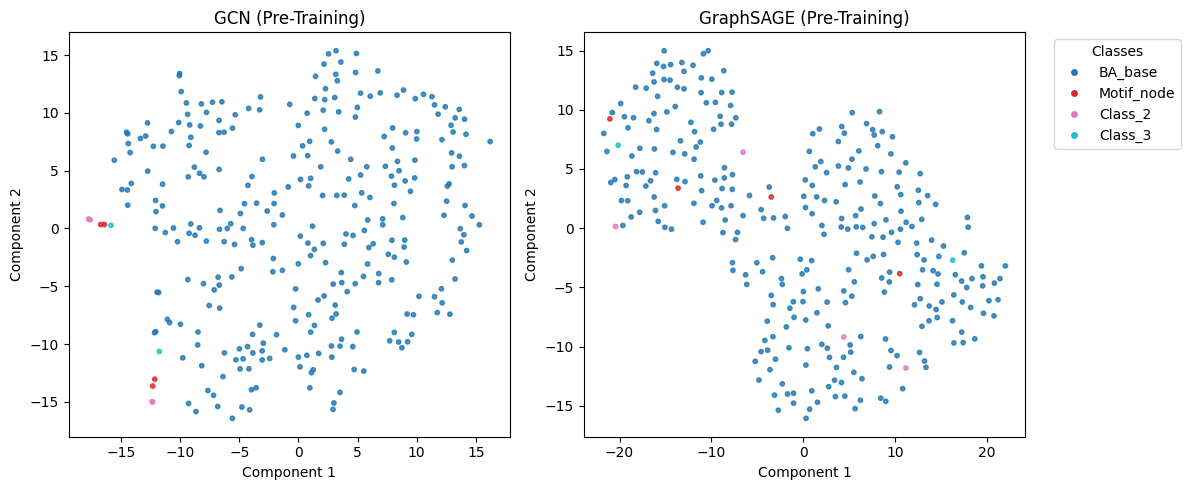

In [5]:
with torch.no_grad():
    gcn_model.eval()
    graphsage_model.eval()
    pre_gcn_logits = gcn_model(data.x, data.edge_index)
    pre_sage_logits = graphsage_model(data.x, data.edge_index)

pre_gcn_coords = tsne_project(pre_gcn_logits)
pre_sage_coords = tsne_project(pre_sage_logits)
plot_embeddings(pre_gcn_coords, pre_sage_coords, "(Pre-Training)")

## Training Utilities
Set up loss functions, optimizers, and helper routines to train and evaluate both models.

In [6]:
loss_fn = nn.CrossEntropyLoss()

train_mask = data.train_mask
val_mask = data.val_mask
test_mask = data.test_mask

# Increased weight_decay for GCN to reduce overfitting (5e-4 -> 5e-3)
# Reduced learning rate for more stable convergence (0.01 -> 0.005)
gcn_optimizer = torch.optim.Adam(gcn_model.parameters(), lr=0.005, weight_decay=5e-3)
graphsage_optimizer = torch.optim.Adam(graphsage_model.parameters(), lr=0.01, weight_decay=5e-4)

def train_gcn() -> tuple[float, float]:
    gcn_model.train()
    gcn_optimizer.zero_grad()
    logits = gcn_model(data.x, data.edge_index)
    loss = loss_fn(logits[train_mask], labels[train_mask])
    loss.backward()
    gcn_optimizer.step()
    preds = logits.argmax(dim=-1)
    train_acc = (preds[train_mask] == labels[train_mask]).float().mean().item()
    return loss.item(), train_acc

def train_graphsage() -> tuple[float, float]:
    graphsage_model.train()
    graphsage_optimizer.zero_grad()
    logits = graphsage_model(data.x, data.edge_index)
    loss = loss_fn(logits[train_mask], labels[train_mask])
    loss.backward()
    graphsage_optimizer.step()
    preds = logits.argmax(dim=-1)
    train_acc = (preds[train_mask] == labels[train_mask]).float().mean().item()
    return loss.item(), train_acc

@torch.no_grad()
def evaluate_gcn(mask: torch.Tensor):
    gcn_model.eval()
    logits = gcn_model(data.x, data.edge_index)
    preds = logits.argmax(dim=-1)
    loss = loss_fn(logits[mask], labels[mask])
    acc = (preds[mask] == labels[mask]).float().mean().item()
    return loss.item(), acc, preds

@torch.no_grad()
def evaluate_graphsage(mask: torch.Tensor):
    graphsage_model.eval()
    logits = graphsage_model(data.x, data.edge_index)
    preds = logits.argmax(dim=-1)
    loss = loss_fn(logits[mask], labels[mask])

    acc = (preds[mask] == labels[mask]).float().mean().item()    
    return loss.item(), acc, preds

## Train Models
Run a joint training loop and monitor validation loss/accuracy for both architectures.

In [7]:
# Early stopping for GCN to prevent overfitting
gcn_epochs = 1000
best_val_loss = float('inf')
patience = 100  # Stop if no improvement for 100 epochs
patience_counter = 0

for epoch in range(1, gcn_epochs + 1):
    gcn_loss, gcn_train_acc = train_gcn()
    gcn_val_loss, gcn_val_acc, _ = evaluate_gcn(val_mask)
    
    # Early stopping check
    if gcn_val_loss < best_val_loss:
        best_val_loss = gcn_val_loss
        patience_counter = 0
    else:
        patience_counter += 1
    
    if epoch == 1 or epoch % 20 == 0 or epoch == gcn_epochs:
        print(
            f"[GCN] Epoch {epoch:03d} | "
            f"train {gcn_loss:.4f} (acc {gcn_train_acc:.4f}) / "
            f"val {gcn_val_loss:.4f} (acc {gcn_val_acc:.4f}) | "
            f"best_val {best_val_loss:.4f}"
        )
    
    if patience_counter >= patience:
        print(f"[GCN] Early stopping at epoch {epoch} (best val loss: {best_val_loss:.4f})")
        break

graphsage_epochs = 1000
best_sage_val_loss = float('inf')
sage_patience = 100
sage_patience_counter = 0

for epoch in range(1, graphsage_epochs + 1):
    sage_loss, sage_train_acc = train_graphsage()
    sage_val_loss, sage_val_acc, _ = evaluate_graphsage(val_mask)

    if sage_val_loss < best_sage_val_loss:
        best_sage_val_loss = sage_val_loss
        sage_patience_counter = 0
    else:
        sage_patience_counter += 1

    if epoch == 1 or epoch % 20 == 0 or epoch == graphsage_epochs:
        print(
            f"[GraphSAGE] Epoch {epoch:03d} | "
            f"train {sage_loss:.4f} (acc {sage_train_acc:.4f}) / "
            f"val {sage_val_loss:.4f} (acc {sage_val_acc:.4f}) | "
            f"best_val {best_sage_val_loss:.4f}"
        )

    if sage_patience_counter >= sage_patience:
        print(f"[GraphSAGE] Early stopping at epoch {epoch} (best val loss: {best_sage_val_loss:.4f})")
        break

[GCN] Epoch 001 | train 1.3017 (acc 0.7419) / val 1.2676 (acc 0.9194) | best_val 1.2676
[GCN] Epoch 020 | train 0.3718 (acc 0.9839) / val 0.5024 (acc 0.9355) | best_val 0.5024
[GCN] Epoch 040 | train 0.1333 (acc 0.9839) / val 0.3758 (acc 0.9355) | best_val 0.3758
[GCN] Epoch 060 | train 0.0889 (acc 0.9839) / val 0.3471 (acc 0.9355) | best_val 0.3471
[GCN] Epoch 080 | train 0.0763 (acc 0.9839) / val 0.2993 (acc 0.9355) | best_val 0.2993
[GCN] Epoch 100 | train 0.0576 (acc 0.9839) / val 0.2618 (acc 0.9355) | best_val 0.2618
[GCN] Epoch 120 | train 0.0522 (acc 0.9839) / val 0.2387 (acc 0.9355) | best_val 0.2387
[GCN] Epoch 140 | train 0.0500 (acc 0.9839) / val 0.2177 (acc 0.9355) | best_val 0.2177
[GCN] Epoch 160 | train 0.0481 (acc 0.9839) / val 0.2053 (acc 0.9355) | best_val 0.2053
[GCN] Epoch 180 | train 0.0412 (acc 0.9839) / val 0.1913 (acc 0.9355) | best_val 0.1913
[GCN] Epoch 200 | train 0.0360 (acc 0.9892) / val 0.1811 (acc 0.9355) | best_val 0.1811
[GCN] Epoch 220 | train 0.0394 (

## Evaluate on Test Set
Measure final performance and compare a handful of predicted labels against the ground truth.

In [8]:
gcn_test_loss, gcn_test_acc, gcn_preds = evaluate_gcn(test_mask)
sage_test_loss, sage_test_acc, sage_preds = evaluate_graphsage(test_mask)

print(f"GCN test loss {gcn_test_loss:.4f}, accuracy {gcn_test_acc:.4f}")
print(f"GraphSAGE test loss {sage_test_loss:.4f}, accuracy {sage_test_acc:.4f}")

test_indices = test_mask.nonzero(as_tuple=False).view(-1)
sample_count = min(10, test_indices.numel())
sample_indices = test_indices[:sample_count]

if sample_count == 0:
    print("No test nodes available in the current split.")
else:
    print("\nSample predictions on test nodes:")
    for idx in sample_indices:
        idx_int = int(idx.item())
        true_label = int(labels[idx].item())
        gcn_label = int(gcn_preds[idx].item())
        sage_label = int(sage_preds[idx].item())
        print(
            f"Node {idx_int:4d} | True: {true_label} | "
            f"GCN: {gcn_label} | GraphSAGE: {sage_label}"
        )

GCN test loss 0.1332, accuracy 0.9677
GraphSAGE test loss 0.3303, accuracy 0.9516

Sample predictions on test nodes:
Node    1 | True: 0 | GCN: 0 | GraphSAGE: 0
Node   13 | True: 0 | GCN: 0 | GraphSAGE: 0
Node   14 | True: 0 | GCN: 0 | GraphSAGE: 0
Node   20 | True: 0 | GCN: 0 | GraphSAGE: 0
Node   21 | True: 0 | GCN: 0 | GraphSAGE: 0
Node   34 | True: 0 | GCN: 0 | GraphSAGE: 0
Node   43 | True: 0 | GCN: 0 | GraphSAGE: 0
Node   47 | True: 0 | GCN: 0 | GraphSAGE: 0
Node   48 | True: 0 | GCN: 0 | GraphSAGE: 0
Node   49 | True: 0 | GCN: 0 | GraphSAGE: 0


## GNN Explainer Interpretability
Use GNN Explainer to visualise influential subgraphs for sample predictions and quantify explanation quality.

In [9]:
def _normalize_node_mask(node_mask, x: torch.Tensor, node_idx: int) -> torch.Tensor:
    if node_mask is None:
        return torch.ones_like(x)
    if node_mask.dim() == 2:
        if node_mask.shape == x.shape:
            return node_mask
        if node_mask.size(0) == x.size(0) and node_mask.size(1) == 1:
            return node_mask.repeat(1, x.size(-1))
    if node_mask.dim() == 1:
        if node_mask.numel() == x.size(-1):
            expanded = torch.ones_like(x)
            expanded[node_idx] = node_mask
            return expanded
        if node_mask.numel() == x.size(0):
            return node_mask.unsqueeze(-1).repeat(1, x.size(-1))
    if node_mask.dim() == 2 and node_mask.size(1) == x.size(-1):
        return node_mask
    return torch.ones_like(x)

EXPLAINER_PARAMS = {
    "gnn_explainer_epochs": 400,
    "gnn_stability_epochs": 280,
    "pg_explainer_epochs": 50,
    "pg_lr": 0.002,
    "pg_train_sample_size": 120,
    "ig_n_steps": 256,
    "ig_internal_batch_size": 1,
    "stability_runs": 11,
    "edge_selection_quantile": 0.95,
    "edge_selection_min_edges": 14,
}

def _build_target_tensor(node_idx: int, data, labels: torch.Tensor, model: torch.nn.Module) -> tuple[torch.Tensor, int]:
    """Build target tensor based on model's actual prediction, not ground truth."""
    with torch.no_grad():
        logits = model(data.x, data.edge_index)
        predicted_class = int(logits[node_idx].argmax().item())
    
    target_tensor = torch.full(
        (data.num_nodes,),
        predicted_class,
        dtype=labels.dtype,
        device=labels.device,
    )
    return target_tensor, predicted_class

def _prepare_edge_subset(
    edge_index: torch.Tensor,
    edge_mask: torch.Tensor,
    selection: torch.Tensor,
    max_edges: Optional[int] = None,
    inverse: bool = False,
) -> tuple[torch.Tensor, torch.Tensor]:
    """Prepare edge subset based on selection. If inverse=True, selects edges NOT in selection."""
    if inverse:
        # For fidelity: remove important edges (keep unimportant ones)
        selected_idx = (~selection).nonzero(as_tuple=False).view(-1)
    else:
        # For visualization: keep important edges
        selected_idx = selection.nonzero(as_tuple=False).view(-1)
    
    if selected_idx.numel() == 0:
        selected_idx = edge_mask.topk(1).indices
    if max_edges is not None and selected_idx.numel() > max_edges:
        mask_values = edge_mask[selected_idx]
        topk = mask_values.topk(max_edges).indices
        selected_idx = selected_idx[topk]
    sub_edge_index = edge_index[:, selected_idx]
    sub_edge_mask = edge_mask[selected_idx]
    return sub_edge_index, sub_edge_mask

def _plot_explanation(
    node_idx: int,
    edge_index: torch.Tensor,
    edge_mask: torch.Tensor,
    selection: torch.Tensor,
    ax: plt.Axes,
    max_edges: Optional[int] = 20,
):
    sub_edge_index, sub_edge_mask = _prepare_edge_subset(
        edge_index, edge_mask, selection, max_edges=max_edges, inverse=False
    )
    sub_edge_index = sub_edge_index.detach().cpu()
    sub_edge_mask = sub_edge_mask.detach().cpu()

    graph = nx.Graph()
    edges = sub_edge_index.t().tolist()
    weights = sub_edge_mask.tolist() if sub_edge_mask.numel() > 0 else []
    nodes = set()
    for idx, (src, dst) in enumerate(edges):
        weight = weights[idx] if idx < len(weights) else 0.0
        graph.add_edge(src, dst, weight=float(weight))
        nodes.add(src)
        nodes.add(dst)
    nodes.add(node_idx)
    graph.add_nodes_from(nodes)

    if node_idx not in graph:
        graph.add_node(node_idx)

    for node in graph.nodes():
        label_val = int(labels[node].item())
        graph.nodes[node]["label"] = label_name_map.get(label_val, str(label_val))

    pos = nx.spring_layout(graph, seed=42)
    node_colors = ["#ff7f0e" if node == node_idx else "#1f77b4" for node in graph.nodes()]

    nx.draw_networkx_nodes(
        graph,
        pos,
        node_color=node_colors,
        node_size=300,
        alpha=0.9,
        ax=ax,
    )
    if graph.number_of_edges() > 0:
        edge_weights = [max(float(data.get("weight", 0.0)), 0.0) for _, _, data in graph.edges(data=True)]
        w_min = min(edge_weights)
        w_max = max(edge_weights)
        if w_max - w_min < 1e-9:
            norm_vals = [0.5 for _ in edge_weights]
        else:
            norm_vals = [(w - w_min) / (w_max - w_min) for w in edge_weights]
        edge_colors = [plt.cm.Reds(v) for v in norm_vals]
        edge_widths = [1.5 + 2.5 * v for v in norm_vals]
        nx.draw_networkx_edges(
            graph,
            pos,
            edge_color=edge_colors,
            width=edge_widths,
            ax=ax,
        )
    nx.draw_networkx_labels(
        graph,
        pos,
        labels={n: graph.nodes[n]["label"] for n in graph.nodes()},
        font_size=8,
        ax=ax,
    )
    ax.set_axis_off()

def run_gnn_explainer(model: torch.nn.Module, node_idx: int, data, epochs: Optional[int] = None):
    model.eval()
    epochs = EXPLAINER_PARAMS["gnn_explainer_epochs"] if epochs is None else epochs
    target_tensor, predicted_class = _build_target_tensor(node_idx, data, labels, model)
    explainer = Explainer(
        model=model,
        algorithm=GNNExplainer(epochs=epochs),
        explanation_type="phenomenon",
        model_config=ModelConfig(
            mode="multiclass_classification",
            task_level="node",
            return_type="raw",
        ),
        node_mask_type="attributes",
        edge_mask_type="object",
    )
    explanation = explainer(
        data.x,
        data.edge_index,
        index=node_idx,
        target=target_tensor,
    )
    edge_mask = explanation.edge_mask
    if edge_mask is None:
        edge_mask = torch.zeros(data.edge_index.size(1), device=data.edge_index.device)
    node_feat_mask = _normalize_node_mask(explanation.node_mask, data.x, node_idx).to(data.x.device)
    edge_mask = edge_mask.to(data.edge_index.device)
    return explainer, explanation, node_feat_mask, edge_mask, predicted_class

def run_pg_explainer(
    model: torch.nn.Module,
    node_idx: int,
    data,
    epochs: Optional[int] = None,
    lr: Optional[float] = None,
    train_sample_size: Optional[int] = None,
):
    """Run PGExplainer - a parameterized explainer that learns to explain."""
    model.eval()
    epochs = EXPLAINER_PARAMS["pg_explainer_epochs"] if epochs is None else epochs
    lr = EXPLAINER_PARAMS["pg_lr"] if lr is None else lr
    train_sample_size = EXPLAINER_PARAMS["pg_train_sample_size"] if train_sample_size is None else train_sample_size
    target_tensor, predicted_class = _build_target_tensor(node_idx, data, labels, model)
    explainer = Explainer(
        model=model,
        algorithm=PGExplainer(epochs=epochs, lr=lr),
        explanation_type="phenomenon",
        model_config=ModelConfig(
            mode="multiclass_classification",
            task_level="node",
            return_type="raw",
        ),
        node_mask_type=None,  # PGExplainer doesn't support node feature masking
        edge_mask_type="object",
    )
    
    # PGExplainer needs training on a SUBSET of nodes (not all!)
    # Training on all 2708 nodes would take too long
    train_indices = data.train_mask.nonzero(as_tuple=False).view(-1)
    # Use only a configurable number of random training nodes for efficiency
    import random
    sample_size = min(train_sample_size, train_indices.numel())
    sampled_indices = random.sample(train_indices.tolist(), sample_size)
    
    for epoch in range(epochs):
        for index in sampled_indices:
            loss = explainer.algorithm.train(
                epoch, model, data.x, data.edge_index, target=target_tensor, index=index
            )
    
    explanation = explainer(
        data.x,
        data.edge_index,
        index=node_idx,
        target=target_tensor,
    )
    edge_mask = explanation.edge_mask
    if edge_mask is None:
        edge_mask = torch.zeros(data.edge_index.size(1), device=data.edge_index.device)
    # PGExplainer only provides edge masks, so use uniform node feature mask
    node_feat_mask = torch.ones_like(data.x)
    edge_mask = edge_mask.to(data.edge_index.device)
    return explainer, explanation, node_feat_mask, edge_mask, predicted_class

def build_edge_selection(edge_mask: torch.Tensor) -> torch.Tensor:
    if edge_mask.numel() == 0:
        return torch.zeros_like(edge_mask, dtype=torch.bool)
    q = EXPLAINER_PARAMS["edge_selection_quantile"]
    min_edges = min(EXPLAINER_PARAMS["edge_selection_min_edges"], edge_mask.numel())
    threshold = torch.quantile(edge_mask, q)
    selection = (edge_mask >= threshold).to(torch.bool)
    if int(selection.sum().item()) < min_edges:
        top_idx = edge_mask.topk(min_edges).indices
        selection = torch.zeros_like(edge_mask, dtype=torch.bool)
        selection[top_idx] = True
    return selection

def compute_explanation_metrics(
    model: torch.nn.Module,
    data,
    node_idx: int,
    node_feat_mask: torch.Tensor,
    edge_mask: torch.Tensor,
    selection: torch.Tensor,
    target_class: int,
) -> dict:
    x, edge_index = data.x, data.edge_index
    true_class = int(labels[node_idx].item())
    is_correct = (target_class == true_class)
    
    with torch.no_grad():
        # Full prediction (with all features and edges)
        logits = model(x, edge_index)
        probs = logits.softmax(dim=-1)
        full_prob = float(probs[node_idx, target_class].item())

        # Fidelity: REMOVE important features and edges to see prediction drop
        # Invert the masks to remove important parts
        inverse_node_feat_mask = 1.0 - node_feat_mask
        masked_x = x * inverse_node_feat_mask
        
        # Keep only unimportant edges (remove important ones)
        masked_edge_index, _ = _prepare_edge_subset(edge_index, edge_mask, selection, inverse=True)
        masked_logits = model(masked_x, masked_edge_index)
        masked_probs = masked_logits.softmax(dim=-1)
        masked_prob = float(masked_probs[node_idx, target_class].item())

    # Fidelity should be < 1 (prediction drops when removing important parts)
    fidelity = masked_prob / (full_prob + 1e-9) if full_prob > 0 else float("nan")
    
    # Probability drop (should be negative - prediction gets worse)
    prob_drop = masked_prob - full_prob
    
    sparsity = 1.0 - float(selection.float().mean().item())
    edge_keep = float(selection.float().mean().item())

    return {
        "predicted_class": target_class,
        "true_class": true_class,
        "is_correct": is_correct,
        "full_prob": full_prob,
        "masked_prob": masked_prob,
        "fidelity": fidelity,
        "prob_drop": prob_drop,
        "sparsity": sparsity,
        "edge_fraction_kept": edge_keep,
    }

def estimate_stability(
    model: torch.nn.Module,
    data,
    node_idx: int,
    runs: Optional[int] = None,
) -> float:
    runs = EXPLAINER_PARAMS["stability_runs"] if runs is None else runs
    edge_masks: List[torch.Tensor] = []
    x, edge_index = data.x, data.edge_index
    cpu_state = torch.get_rng_state()
    cuda_states = torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None
    try:
        for seed in range(runs):
            torch.manual_seed(seed)
            if torch.cuda.is_available():
                torch.cuda.manual_seed_all(seed)
            target_tensor, _ = _build_target_tensor(node_idx, data, labels, model)
            explainer = Explainer(
                model=model,
                algorithm=GNNExplainer(epochs=EXPLAINER_PARAMS["gnn_stability_epochs"]),
                explanation_type="phenomenon",
                model_config=ModelConfig(
                    mode="multiclass_classification",
                    task_level="node",
                    return_type="raw",
                ),
                node_mask_type="attributes",
                edge_mask_type="object",
            )
            explanation = explainer(
                x,
                edge_index,
                index=node_idx,
                target=target_tensor,
            )
            mask = explanation.edge_mask
            if mask is None:
                mask = torch.zeros(edge_index.size(1), device=x.device)
            edge_masks.append(mask.to(x.device))
    finally:
        torch.set_rng_state(cpu_state)
        if cuda_states is not None:
            torch.cuda.set_rng_state_all(cuda_states)

    if not edge_masks:
        return float("nan")

    stacked = torch.stack(edge_masks)
    stability = 1.0 - float(stacked.var(dim=0).mean().item())
    return stability

def _derive_edge_mask_from_node_mask(node_mask: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
    """Derive edge importance from node-level attributions.
    For each edge (u, v), importance = (node_imp[u] + node_imp[v]) / 2.
    """
    if node_mask is None:
        return torch.zeros(edge_index.size(1), device=edge_index.device)
    if node_mask.dim() == 2:
        node_imp = node_mask.abs().norm(dim=1)
    else:
        node_imp = node_mask.abs()
    if node_imp.max() > 0:
        node_imp = node_imp / node_imp.max()
    src, dst = edge_index[0], edge_index[1]
    return ((node_imp[src] + node_imp[dst]) / 2.0).detach()

def run_integrated_gradients(model: torch.nn.Module, node_idx: int, data):
    """
    Run Integrated Gradients using Captum directly (bypassing CaptumExplainer).
    
    CaptumExplainer is incompatible with GCNConv because:
    1) GCNConv adds self-loops, changing edge_index size vs the edge mask
    2) Captum's batched IG slices edge_index along dim 0, corrupting [2,E] -> [1,E]
    We avoid both issues by capturing edge_index in a closure.
    
    Returns: (None, explanation_dict, node_feat_mask, edge_mask, predicted_class)
    """
    model.eval()
    _, predicted_class = _build_target_tensor(node_idx, data, labels, model)
    
    x = data.x.clone()
    edge_index = data.edge_index  # captured in closure - Captum never touches it
    
    def forward_func(x_input):
        out = model(x_input.squeeze(0), edge_index)
        return out[node_idx].unsqueeze(0)  # [1, num_classes]
    
    ig = CaptumIG(forward_func)
    attributions = ig.attribute(
        x.unsqueeze(0),           # [1, num_nodes, num_features]
        target=predicted_class,   # scalar int
        internal_batch_size=EXPLAINER_PARAMS["ig_internal_batch_size"],
        n_steps=EXPLAINER_PARAMS["ig_n_steps"],
    )
    node_mask = attributions.squeeze(0).detach()  # [num_nodes, num_features]
    
    node_feat_mask = _normalize_node_mask(node_mask, data.x, node_idx).to(dtype=data.x.dtype, device=data.x.device)
    edge_mask = _derive_edge_mask_from_node_mask(node_mask, data.edge_index)
    edge_mask = edge_mask.to(dtype=data.x.dtype, device=data.edge_index.device)
    
    explanation = {"node_mask": node_mask, "edge_mask": edge_mask, "predicted_class": predicted_class}
    return None, explanation, node_feat_mask, edge_mask, predicted_class

def estimate_ig_stability(
    model: torch.nn.Module,
    node_idx: int,
    data,
    runs: Optional[int] = None,
) -> float:
    """Estimate stability of Integrated Gradients using Captum directly."""
    runs = EXPLAINER_PARAMS["stability_runs"] if runs is None else runs
    edge_masks: List[torch.Tensor] = []
    x, edge_index = data.x, data.edge_index
    cpu_state = torch.get_rng_state()
    cuda_states = torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None
    
    try:
        for seed in range(runs):
            torch.manual_seed(seed)
            if torch.cuda.is_available():
                torch.cuda.manual_seed_all(seed)
            
            _, predicted_class = _build_target_tensor(node_idx, data, labels, model)
            
            def forward_func(x_input, _ei=edge_index, _nidx=node_idx):
                out = model(x_input.squeeze(0), _ei)
                return out[_nidx].unsqueeze(0)
            
            ig = CaptumIG(forward_func)
            attributions = ig.attribute(
                x.unsqueeze(0), target=predicted_class,
                internal_batch_size=EXPLAINER_PARAMS["ig_internal_batch_size"], n_steps=EXPLAINER_PARAMS["ig_n_steps"],
            )
            node_mask = attributions.squeeze(0).detach()
            mask = _derive_edge_mask_from_node_mask(node_mask, edge_index)
            edge_masks.append(mask.to(x.device))
    finally:
        torch.set_rng_state(cpu_state)
        if cuda_states is not None:
            torch.cuda.set_rng_state_all(cuda_states)

    if not edge_masks:
        return float("nan")

    stacked = torch.stack(edge_masks)
    return 1.0 - float(stacked.var(dim=0).mean().item())

In [10]:
def explain_and_report(
    model: torch.nn.Module,
    model_name: str,
    explainer_name: str,
    explainer_fn,
    data,
    node_idx: int,
    runs: Optional[int] = None,
    max_edges: int = 20,
) -> dict:
    """Run explainer and generate metrics and visualization."""
    print(f"\nRunning {explainer_name} for {model_name}...")
    runs = EXPLAINER_PARAMS["stability_runs"] if runs is None else runs
    
    explainer, explanation, node_feat_mask, edge_mask, predicted_class = explainer_fn(model, node_idx, data)
    selection = build_edge_selection(edge_mask)
    metrics = compute_explanation_metrics(
        model,
        data,
        node_idx,
        node_feat_mask,
        edge_mask,
        selection,
        predicted_class,
    )
    metrics["stability"] = estimate_stability(model, data, node_idx, runs=runs)

    fig, ax = plt.subplots(figsize=(6, 6))
    _plot_explanation(
        node_idx=node_idx,
        edge_index=data.edge_index,
        edge_mask=edge_mask,
        selection=selection,
        ax=ax,
        max_edges=max_edges,
    )
    ax.set_title(f"{model_name} - {explainer_name}\n(node {node_idx})")
    plt.show()

    print(f"{model_name} - {explainer_name} metrics:")
    print(f"  predicted_class: {metrics['predicted_class']} ({label_name_map[metrics['predicted_class']]})")
    print(f"  true_class: {metrics['true_class']} ({label_name_map[metrics['true_class']]})")
    print(f"  is_correct: {metrics['is_correct']}")
    for key, value in metrics.items():
        if key not in ['predicted_class', 'true_class', 'is_correct']:
            print(f"  {key}: {value:.4f}")

    return {
        "explainer": explainer_name,
        "model": model_name,
        "explanation": explanation,
        "node_feat_mask": node_feat_mask,
        "edge_mask": edge_mask,
        "metrics": metrics,
    }

def compare_explainers(results: List[dict]) -> pd.DataFrame:
    """Create a comparison table of explainer metrics."""
    comparison_data = []
    for result in results:
        row = {
            "Model": result["model"],
            "Explainer": result["explainer"],
            **result["metrics"]
        }
        comparison_data.append(row)
    
    df = pd.DataFrame(comparison_data)
    # Reorder columns for better readability
    cols = ["Model", "Explainer", "is_correct", "fidelity", "prob_drop", "sparsity", 
            "edge_fraction_kept", "stability", "full_prob", "masked_prob"]
    df = df[[c for c in cols if c in df.columns]]
    return df

Explaining node 34 with label 0 (BA_base)

Running GNNExplainer for GCN...


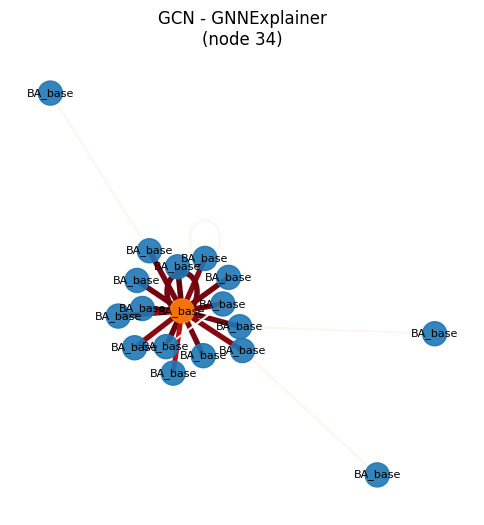

GCN - GNNExplainer metrics:
  predicted_class: 0 (BA_base)
  true_class: 0 (BA_base)
  is_correct: True
  full_prob: 0.9990
  masked_prob: 0.8345
  fidelity: 0.8353
  prob_drop: -0.1645
  sparsity: 0.9500
  edge_fraction_kept: 0.0500
  stability: 1.0000

Running PGExplainer for GCN...


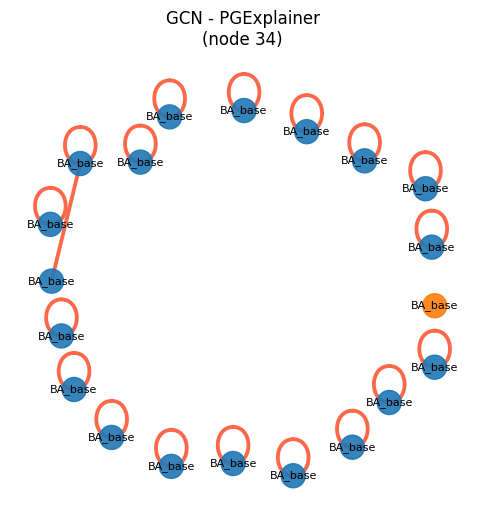

GCN - PGExplainer metrics:
  predicted_class: 0 (BA_base)
  true_class: 0 (BA_base)
  is_correct: True
  full_prob: 0.9990
  masked_prob: 0.9965
  fidelity: 0.9975
  prob_drop: -0.0025
  sparsity: 0.0000
  edge_fraction_kept: 1.0000
  stability: 1.0000

Running GNNExplainer for GraphSAGE...


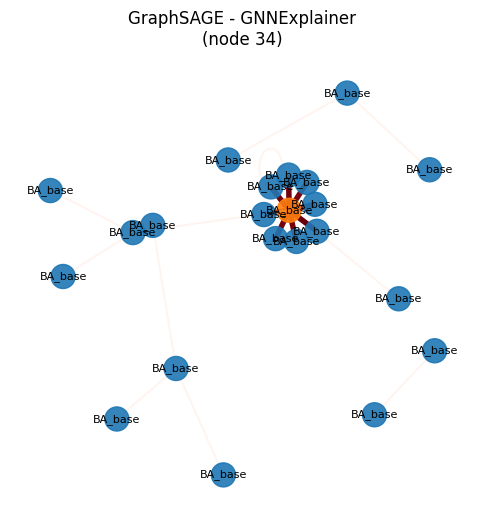

GraphSAGE - GNNExplainer metrics:
  predicted_class: 0 (BA_base)
  true_class: 0 (BA_base)
  is_correct: True
  full_prob: 0.9985
  masked_prob: 0.9273
  fidelity: 0.9287
  prob_drop: -0.0712
  sparsity: 0.9500
  edge_fraction_kept: 0.0500
  stability: 0.9998

Running PGExplainer for GraphSAGE...


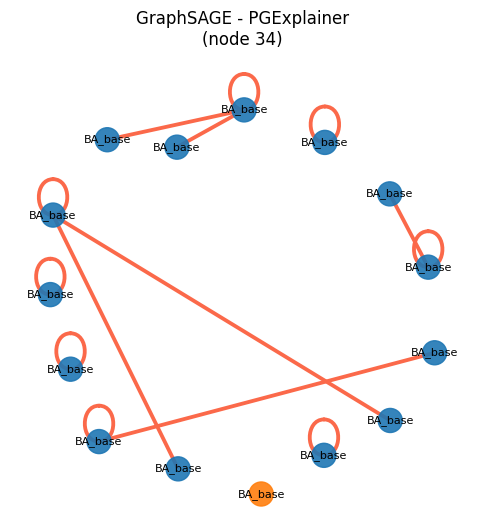

GraphSAGE - PGExplainer metrics:
  predicted_class: 0 (BA_base)
  true_class: 0 (BA_base)
  is_correct: True
  full_prob: 0.9985
  masked_prob: 0.9588
  fidelity: 0.9603
  prob_drop: -0.0396
  sparsity: 0.9500
  edge_fraction_kept: 0.0500
  stability: 0.9998

EXPLAINER COMPARISON
    Model    Explainer  is_correct  fidelity  prob_drop  sparsity  edge_fraction_kept  stability  full_prob  masked_prob
      GCN GNNExplainer        True  0.835311  -0.164520  0.949968            0.050032   0.999983   0.998975     0.834455
      GCN  PGExplainer        True  0.997477  -0.002520  0.000000            1.000000   0.999983   0.998975     0.996455
GraphSAGE GNNExplainer        True  0.928734  -0.071158  0.949968            0.050032   0.999807   0.998492     0.927334
GraphSAGE  PGExplainer        True  0.960296  -0.039644  0.949968            0.050032   0.999807   0.998492     0.958848

Metrics Guide:
  - fidelity: Lower is better (< 0.5 excellent, < 0.7 good)
  - prob_drop: More negative is better

In [11]:
test_nodes = test_mask.nonzero(as_tuple=False).view(-1)
if test_nodes.numel() == 0:
    raise ValueError("No test nodes available for explanation.")

# Choose sample node - modify this to select different nodes:
# Option 1: Pick by index (0 = first test node, 1 = second, etc.)
sample_idx = 5  # Change this number to select different test nodes

# Option 2: Uncomment to pick a random test node
# import random
# sample_idx = random.randint(0, test_nodes.numel() - 1)

# Option 3: Uncomment to use a specific node ID directly (if you know it)
# sample_node = 123  # Replace with specific node ID

sample_node = int(test_nodes[sample_idx].item())
print(f"Explaining node {sample_node} with label {int(labels[sample_node].item())} ({label_name_map[int(labels[sample_node].item())]})")

# Run all explainers for both models
results = []

# GCN with explainers
results.append(explain_and_report(gcn_model, "GCN", "GNNExplainer", run_gnn_explainer, data, sample_node))
results.append(explain_and_report(gcn_model, "GCN", "PGExplainer", run_pg_explainer, data, sample_node))

# GraphSAGE with explainers
results.append(explain_and_report(graphsage_model, "GraphSAGE", "GNNExplainer", run_gnn_explainer, data, sample_node))
results.append(explain_and_report(graphsage_model, "GraphSAGE", "PGExplainer", run_pg_explainer, data, sample_node))

# Create comparison table
comparison_df = compare_explainers(results)
print("\n" + "="*80)
print("EXPLAINER COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))
print("\nMetrics Guide:")
print("  - fidelity: Lower is better (< 0.5 excellent, < 0.7 good)")
print("  - prob_drop: More negative is better (shows prediction degradation)")
print("  - sparsity: Higher is better (more compact explanation)")
print("  - stability: Higher is better (closer to 1.0 = more consistent)")


## Integrated Gradients Explanation
Use Integrated Gradients via Captum to compute gradient-based importance scores for node features, then derive edge importance from node attributions.


Integrated Gradients — GCN

--- Test node 34 ---
  Predicted: 0 | True: 0 | CORRECT


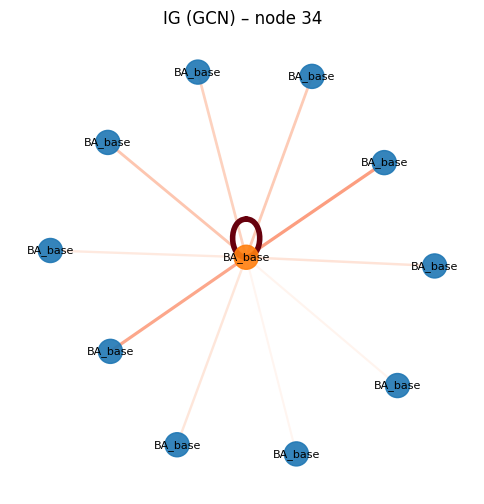

  Fidelity  : 0.2031
  Prob drop : -0.7961
  Stability : 1.0000

Integrated Gradients — GraphSAGE

--- Test node 34 ---
  Predicted: 0 | True: 0 | CORRECT


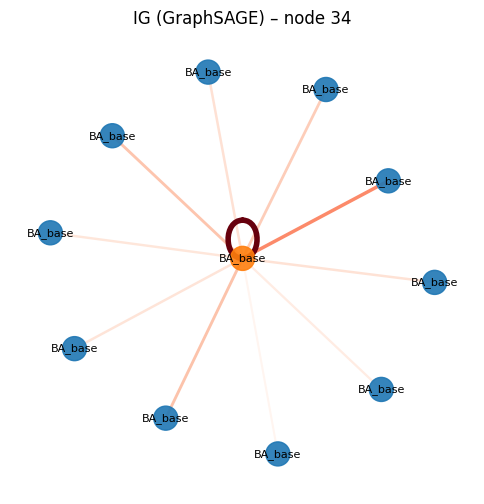

  Fidelity  : 0.8567
  Prob drop : -0.1431
  Stability : 1.0000


In [12]:
ig_results = {}

for model_obj, model_name in [(gcn_model, "GCN"), (graphsage_model, "GraphSAGE")]:
    print(f"\n{'='*60}")
    print(f"Integrated Gradients — {model_name}")
    print(f"{'='*60}")
    print(f"\n--- Test node {sample_node} ---")

    # Run IG on the same sample_node used by GNNExplainer / PGExplainer
    _, ig_explanation, node_feat_mask_ig, edge_mask_ig, pred_class_ig = run_integrated_gradients(
        model_obj, sample_node, data
    )

    # Prediction correctness
    true_label = int(data.y[sample_node].item())
    correct_str = "CORRECT" if pred_class_ig == true_label else "INCORRECT"
    print(f"  Predicted: {pred_class_ig} | True: {true_label} | {correct_str}")

    # Visualise using existing helper
    selection_ig = build_edge_selection(edge_mask_ig)
    fig, ax = plt.subplots(figsize=(6, 6))
    _plot_explanation(
        node_idx=sample_node,
        edge_index=data.edge_index,
        edge_mask=edge_mask_ig,
        selection=selection_ig,
        ax=ax,
        max_edges=20,
    )
    ax.set_title(f"IG ({model_name}) – node {sample_node}")
    plt.show()

    # Fidelity via existing compute_explanation_metrics
    metrics_ig = compute_explanation_metrics(
        model_obj, data, sample_node,
        node_feat_mask_ig, edge_mask_ig, selection_ig, pred_class_ig,
    )
    print(f"  Fidelity  : {metrics_ig['fidelity']:.4f}")
    print(f"  Prob drop : {metrics_ig['prob_drop']:.4f}")

    # Stability
    ig_stability = estimate_ig_stability(model_obj, sample_node, data, runs=EXPLAINER_PARAMS["stability_runs"])
    metrics_ig["stability"] = ig_stability
    print(f"  Stability : {ig_stability:.4f}")

    ig_results[model_name] = {
        "metrics": metrics_ig,
    }

## Unified Explainer Comparison
Combine GNNExplainer, PGExplainer, and Integrated Gradients metrics into a single summary table.

In [13]:
# ── Build unified comparison from GNNExplainer/PGExplainer results and IG results ──
unified_rows = []

# GNNExplainer & PGExplainer metrics from the results list
for r in results:
    m = r["metrics"]
    unified_rows.append({
        "Model":      r["model"],
        "Explainer":  r["explainer"],
        "Predicted":  m["predicted_class"],
        "True":       m["true_class"],
        "Correct":    m["is_correct"],
        "Fidelity":   m["fidelity"],
        "Prob Drop":  m["prob_drop"],
        "Sparsity":   m["sparsity"],
        "Edge Kept":  m["edge_fraction_kept"],
        "Stability":  m["stability"],
    })

# Integrated Gradients metrics from ig_results dict
for model_name, ig_data in ig_results.items():
    m = ig_data["metrics"]
    unified_rows.append({
        "Model":      model_name,
        "Explainer":  "IntegratedGradients",
        "Predicted":  m["predicted_class"],
        "True":       m["true_class"],
        "Correct":    m["is_correct"],
        "Fidelity":   m["fidelity"],
        "Prob Drop":  m["prob_drop"],
        "Sparsity":   m["sparsity"],
        "Edge Kept":  m["edge_fraction_kept"],
        "Stability":  m["stability"],
    })

unified_df = (
    pd.DataFrame(unified_rows)
    .sort_values(["Model", "Explainer"])
    .reset_index(drop=True)
)

print("=" * 90)
print("UNIFIED METRICS — GNNExplainer | PGExplainer | IntegratedGradients")
print("=" * 90)
print(unified_df.to_string(index=False))
print("\nMetrics Guide:")
print("  Fidelity  : Lower → removing explanation degrades prediction more (< 0.5 excellent)")
print("  Prob Drop : More negative → stronger prediction degradation when explanation removed")
print("  Sparsity  : Higher → more compact explanation (fewer edges kept)")
print("  Edge Kept : Fraction of edges retained in the explanation subgraph")
print("  Stability : Higher → explanation is consistent across runs (closer to 1.0)")
print("\nNote: IG edge importance is derived from node feature attributions via Captum.")

UNIFIED METRICS — GNNExplainer | PGExplainer | IntegratedGradients
    Model           Explainer  Predicted  True  Correct  Fidelity  Prob Drop  Sparsity  Edge Kept  Stability
      GCN        GNNExplainer          0     0     True  0.835311  -0.164520  0.949968   0.050032   0.999983
      GCN IntegratedGradients          0     0     True  0.203082  -0.796101  0.929386   0.070614   1.000000
      GCN         PGExplainer          0     0     True  0.997477  -0.002520  0.000000   1.000000   0.999983
GraphSAGE        GNNExplainer          0     0     True  0.928734  -0.071158  0.949968   0.050032   0.999807
GraphSAGE IntegratedGradients          0     0     True  0.856674  -0.143110  0.949652   0.050348   1.000000
GraphSAGE         PGExplainer          0     0     True  0.960296  -0.039644  0.949968   0.050032   0.999807

Metrics Guide:
  Fidelity  : Lower → removing explanation degrades prediction more (< 0.5 excellent)
  Prob Drop : More negative → stronger prediction degradation when e

## Post-Training Embedding Snapshot
Repeat the projection with t-SNE after optimisation to show class separation.

/var/folders/cx/t80f8k7j2h1b0cnx64j7nxg00000gn/T/ipykernel_44154/2766157793.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(label_name_map))


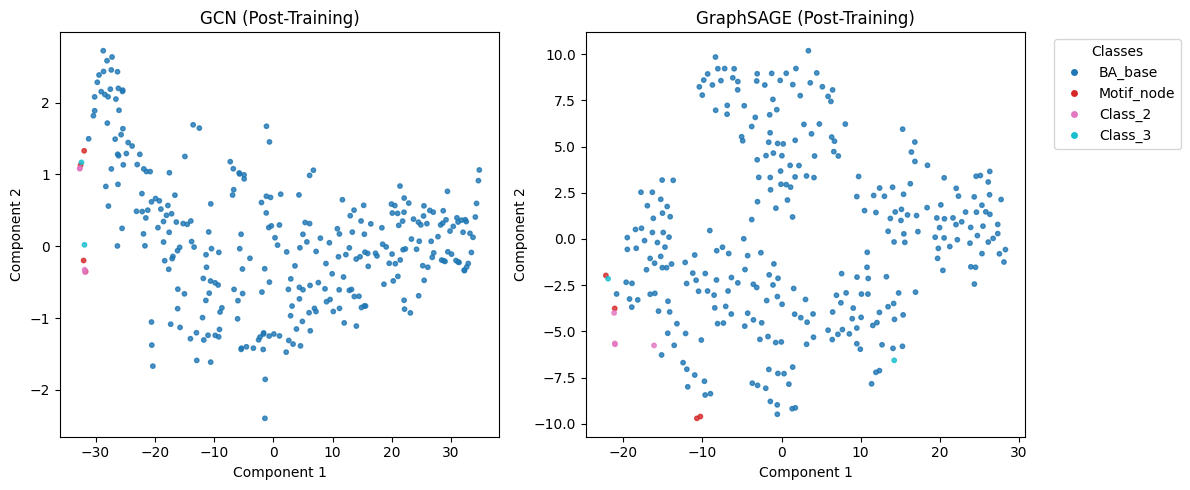

In [14]:
with torch.no_grad():
    gcn_model.eval()
    graphsage_model.eval()
    post_gcn_logits = gcn_model(data.x, data.edge_index)
    post_sage_logits = graphsage_model(data.x, data.edge_index)

post_gcn_coords = tsne_project(post_gcn_logits)
post_sage_coords = tsne_project(post_sage_logits)
plot_embeddings(post_gcn_coords, post_sage_coords, "(Post-Training)")